In [1]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


In [2]:
architecture = [2, 256,256,256,256,3]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 198915


In [3]:
NUM_EPOCHS = 10000
BATCH_SIZE = 1024
FUN_NUM = 2
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.3647942055699372, Acc: 0.3647942055699372
Epoch [999], Loss: 0.0011665957089869979, Acc: 0.0011665957089869979
Epoch [1999], Loss: 0.0007078286457211286, Acc: 0.0007078286457211286
Epoch [2999], Loss: 0.0003368973741893321, Acc: 0.0003368973741893321
Epoch [3999], Loss: 0.00020214993732536735, Acc: 0.00020214993732536735
Epoch [4999], Loss: 0.0001389423434693674, Acc: 0.0001389423434693674
Epoch [5999], Loss: 8.931786884829771e-05, Acc: 8.931786884829771e-05
Epoch [6999], Loss: 8.497242667214034e-05, Acc: 8.497242667214034e-05
Epoch [7999], Loss: 9.672524400274133e-05, Acc: 9.672524400274133e-05
Epoch [8999], Loss: 8.023328827638469e-05, Acc: 8.023328827638469e-05
Epoch [9999], Loss: 8.329784071376164e-05, Acc: 8.329784071376164e-05


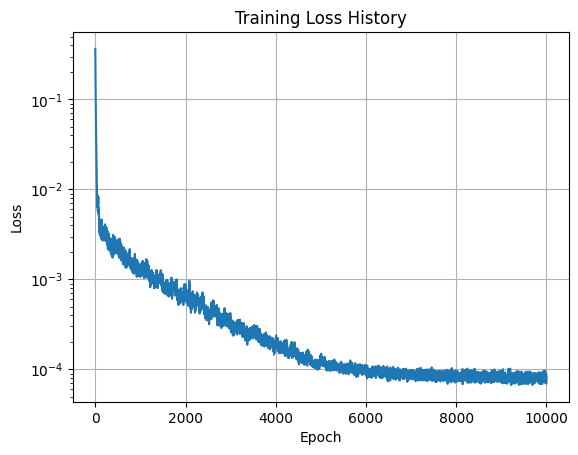

In [4]:
plt.plot(model.loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [5]:
importlib.reload(NI)
NI.evaluate_model_random_points(model, function_case=2,N=10000)

Model evaluation on N=10000 random points (function_case=2):
  Value errors: mean_abs=8.216560e-05, max_abs=1.022928e-02, L2=3.241251e-04
  Grad-norm errors (|grad|-1): mean_abs=7.438809e-03, max_abs=8.903100e-01, L2=4.039388e-02
  Hessian-diagonal errors (target 0): mean_abs=1.214932e+00, max_abs=6.599163e+01, L2=3.852074e+00


{'N': 10000,
 'function_case': 2,
 'global': {'value_mean_abs_error': 8.216559621716106e-05,
  'value_max_abs_error': 0.010229276965572853,
  'value_l2_error': 0.000324125127750168,
  'grad_norm_mean_abs_error': 0.007438808691693368,
  'grad_norm_max_abs_error': 0.8903100005197984,
  'grad_norm_l2_error': 0.040393879920333525,
  'hessian_diag_mean_abs_error': 1.2149324317901635,
  'hessian_diag_max_abs_error': 65.9916263950666,
  'hessian_diag_l2_error': 3.852074158343676}}

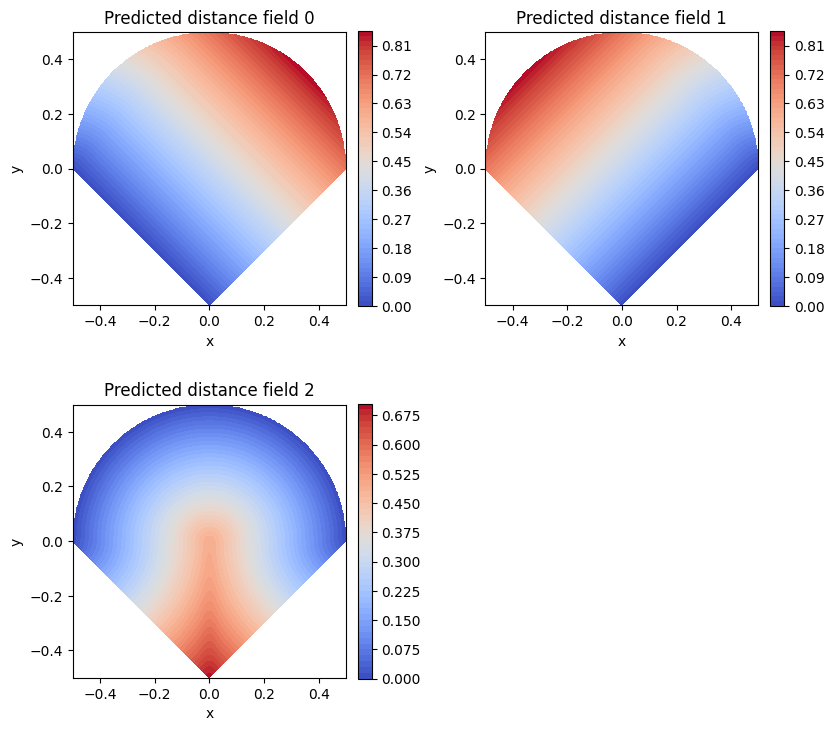

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Predicted distance field 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Predicted distance field 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Predicted distance field 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.32107399, 0.32531369, 0.25769879],
        [0.31919298, 0.32508603, 0.2567783 ],
        [0.31731231, 0.32490313, 0.2558354 ],
        ...,
        [0.61300591, 0.41430357, 0.01765348],
        [0.6103534 , 0.41449428, 0.01897738],
        [0.60768264, 0.4146995 , 0.02035166]]))

In [28]:
NI.plot_nn_distance_fields(model,extent=[-0.5,0.5,-0.5,0.5],fun_num=2,mask_outside_domain=True, device=torch.device('cpu'))

c:\Egyetem\Kutatás\NeuralIGA\.venv\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


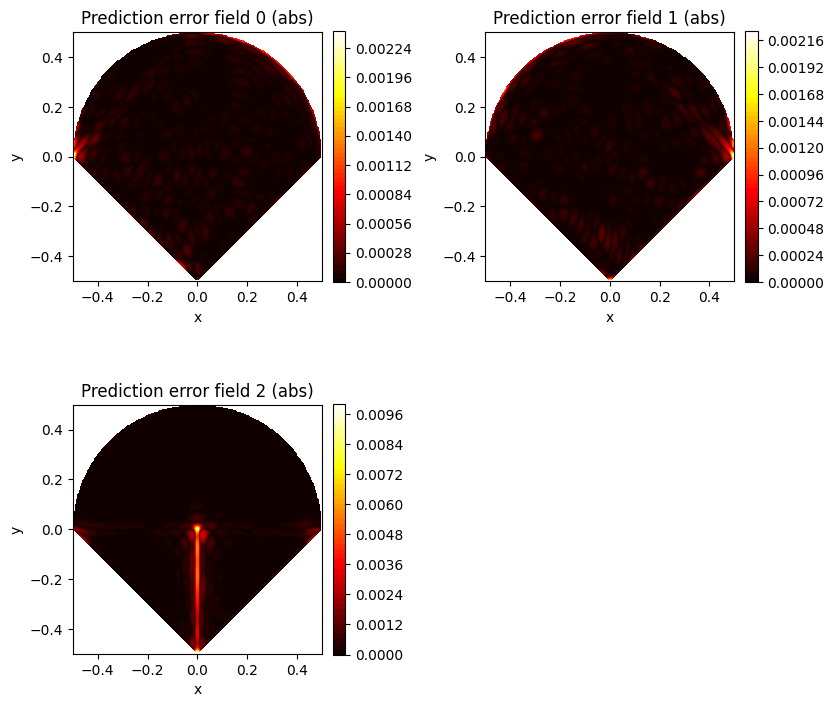

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Prediction error field 0 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Prediction error field 1 (abs)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Prediction error field 2 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.0391808 , 0.17046214, 0.17903183],
        [0.03799631, 0.16769673, 0.17354815],
        [0.03690247, 0.16490445, 0.16834479],
        ...,
        [0.5880571 , 0.03217884, 0.18746868],
        [0.59860357, 0.02844168, 0.18612407],
        [0.60880526, 0.02458983, 0.1846803 ]]))

In [6]:
NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

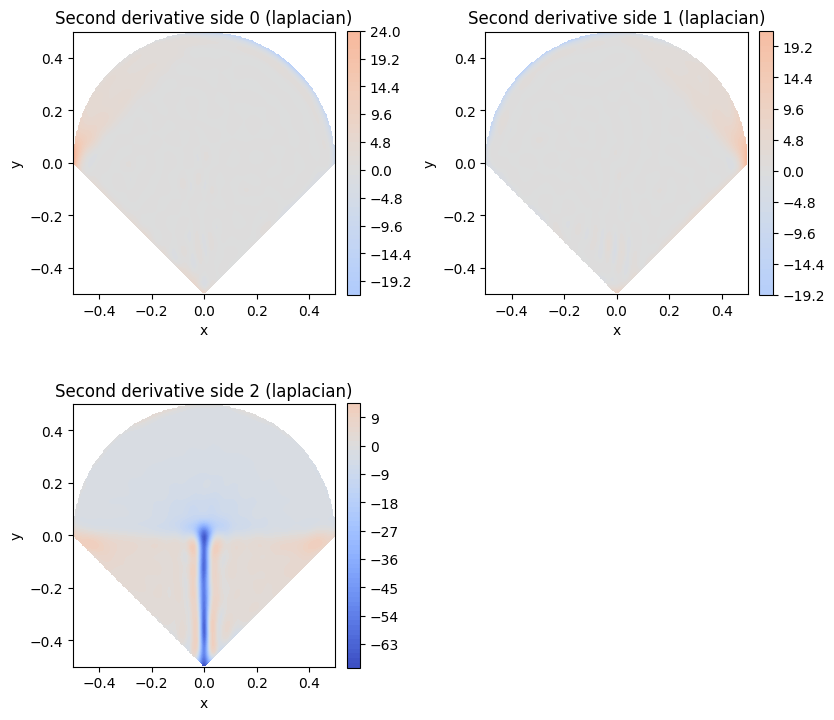

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Second derivative side 0 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Second derivative side 1 (laplacian)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Second derivative side 2 (laplacian)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[-14.5912254 ,  -7.39468855, -11.68584848],
         [-14.91742383,  -7.74645347, -11.81253063],
         [-15.17696025,  -7.95906637, -11.86852381],
         ...,
         [  9.28521851,  23.83668039,  -5.64839031],
         [  9.2093862 ,  24.34001996,  -6.76871644],
         [  9.01204275,  24.78924419,  -7.82248094]],
 
        [[-14.10387592,  -6.98598616, -12.92369711],
         [-14.37832044,  -7.23695472, -13.02465256],
         [-14.58469571,  -7.34436378, -13.04771526],
         ...,
         [  9.61752777,  23.65375351,  -4.98326589],
         [  9.63204287,  24.25229591,  -6.1582596 ],
         [  9.51

In [8]:
NI.plot_local_per_side_second_derivative(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

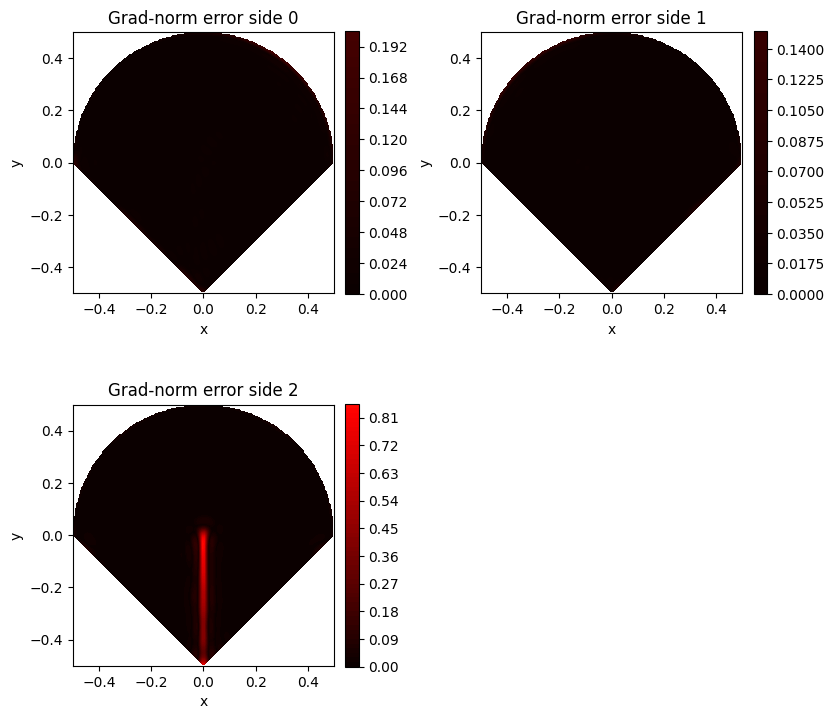

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Grad-norm error side 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Grad-norm error side 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Grad-norm error side 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[6.74630302e-02, 8.29784037e-01, 6.01124246e-01],
         [9.30680177e-02, 8.45153623e-01, 5.83546278e-01],
         [1.19777466e-01, 8.53429845e-01, 5.68125289e-01],
         ...,
         [2.98022352e-01, 8.97061563e-01, 6.92308834e-01],
         [2.94216547e-01, 9.43034084e-01, 7.53071273e-01],
         [2.90940363e-01, 9.81204036e-01, 8.06416333e-01]],
 
        [[1.13910661e-01, 8.26920701e-01, 5.94215295e-01],
         [1.40886401e-01, 8.41278091e-01, 5.75326551e-01],
         [1.68875557e-01, 8.48722165e-01, 5.58562181e-01],
         ...,
         [2.59739431e-01, 8.82723861e-01, 6.68356074e-01],
         [2.56675886e-01, 9.29425811e-01, 7.3205359

In [30]:
NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

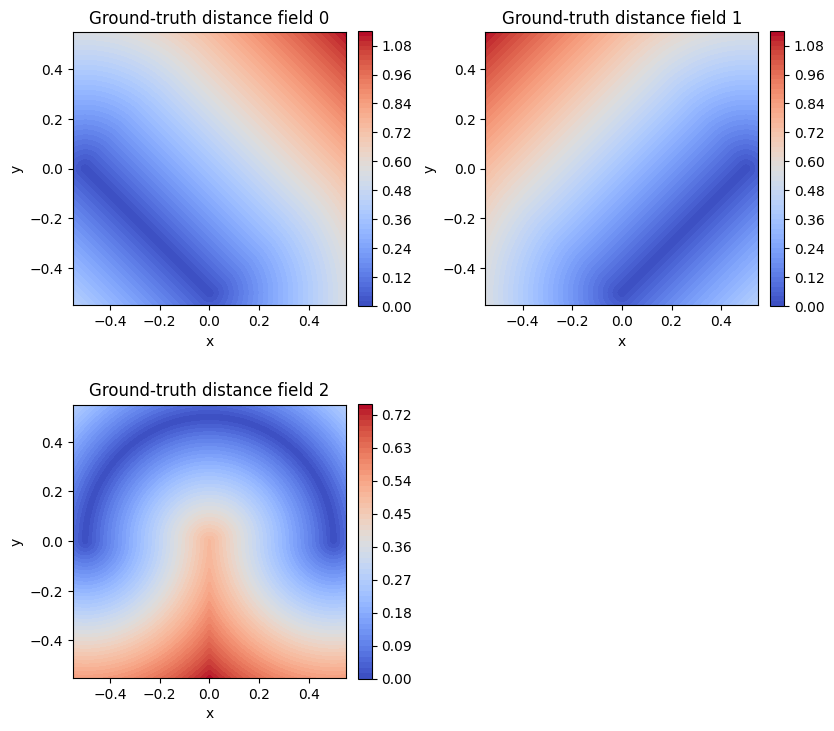

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Ground-truth distance field 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Ground-truth distance field 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Ground-truth distance field 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.42426407, 0.55226805, 0.55226805],
        [0.42166267, 0.55194714, 0.54860433],
        [0.41906128, 0.55165057, 0.54494082],
        ...,
        [1.12616806, 0.54494082, 0.27263218],
        [1.12876945, 0.54860433, 0.27522043],
        [1.13137085, 0.55226805, 0.27781746]]))

In [13]:
importlib.reload(NI)
# Ground-truth visualization for testcase 2 (2 straight sides + 1 curved arc)
case2_params = {
    "radius": 0.5,
    "center": (0.0, 0.0),
    "apex": (0.0, -0.5),
}

NI.plot_ground_truth_distance_fields(
    resolution=300,
    extent=(-0.55, 0.55, -0.55, 0.55),
    fun_num=2,
    data_gen_params=case2_params,
    mask_outside_domain=False,
    device=torch.device('cpu'),
)

In [ ]:
import multi_SDF as SDF
